# Home/Away Performance Splits
Explores whether players perform meaningfully differently at home vs. on the road across PTS, AST, REB, and FG%.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('../data/fact_player_games.csv')
df.head()

,SEASON_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,42024,1628396,Tony Bradley,1610612754,IND,Indiana Pacers,42400407,2025-06-22,IND @ OKC,L,...,1.0,0,1,1,0,0,0,1,2,-2
1,42024,1631097,Bennedict Mathurin,1610612754,IND,Indiana Pacers,42400407,2025-06-22,IND @ OKC,L,...,1.0,7,6,13,3,2,0,3,3,-14
2,42024,1630174,Aaron Nesmith,1610612754,IND,Indiana Pacers,42400407,2025-06-22,IND @ OKC,L,...,NaN,1,5,6,1,2,2,1,6,6
3,42024,1630598,Aaron Wiggins,1610612760,OKC,Oklahoma City Thunder,42400407,2025-06-22,OKC vs. IND,W,...,NaN,0,1,1,0,0,0,0,1,11
4,42024,1627936,Alex Caruso,1610612760,OKC,Oklahoma City Thunder,42400407,2025-06-22,OKC vs. IND,W,...,NaN,2,1,3,0,3,1,0,3,8


## Step 1: Label Home vs. Away
`MATCHUP` contains "vs." for home games and "@" for away games.

In [4]:
df['location'] = df['MATCHUP'].apply(lambda m: 'Home' if 'vs.' in m else 'Away')

print(df['location'].value_counts())
df[['PLAYER_NAME', 'MATCHUP', 'location']].head(8)

location
Home    15013
Away    14987
Name: count, dtype: int64


,PLAYER_NAME,MATCHUP,location
0,Tony Bradley,IND @ OKC,Away
1,Bennedict Mathurin,IND @ OKC,Away
2,Aaron Nesmith,IND @ OKC,Away
3,Aaron Wiggins,OKC vs. IND,Home
4,Alex Caruso,OKC vs. IND,Home
5,Isaiah Hartenstein,OKC vs. IND,Home
6,Ben Sheppard,IND @ OKC,Away
7,Tyrese Haliburton,IND @ OKC,Away


## Step 2: Filter & Aggregate
Minimum qualifiers: **avg MIN >= 10** across all games, **at least 10 qualifying games at each location** (home and away separately).

In [7]:
# Drop players who average fewer than 10 minutes across all their games
avg_min = df.groupby('PLAYER_ID')['MIN'].mean()
qualified_ids = avg_min[avg_min >= 10].index
qualified = df[df['PLAYER_ID'].isin(qualified_ids)].copy()

# Count home and away games per player
loc_counts = (
    qualified.groupby(['PLAYER_ID', 'location'])['GAME_ID']
    .count()
    .unstack(fill_value=0)
)

# Keep only players with at least 10 games at each location
both_loc = loc_counts[(loc_counts.get('Home', 0) >= 10) & (loc_counts.get('Away', 0) >= 10)].index
qualified = qualified[qualified['PLAYER_ID'].isin(both_loc)]

# Aggregate per player per location
agg = (
    qualified
    .groupby(['PLAYER_ID', 'PLAYER_NAME', 'location'])
    .agg(
        games=('GAME_ID', 'count'),
        pts=('PTS', 'mean'),
        ast=('AST', 'mean'),
        reb=('REB', 'mean'),
        fg_pct=('FG_PCT', 'mean'),
    )
    .reset_index()
)

print(f"{agg['PLAYER_ID'].nunique()} players qualify")
agg.head(10)

408 players qualify


,PLAYER_ID,PLAYER_NAME,location,games,pts,ast,reb,fg_pct
0,2544,LeBron James,Away,39,24.076923,8.000000,7.692308,0.494103
1,2544,LeBron James,Home,38,24.078947,7.842105,7.868421,0.517421
2,101108,Chris Paul,Away,43,8.883721,7.093023,3.604651,0.415558
3,101108,Chris Paul,Home,42,8.619048,7.523810,3.523810,0.451810
4,200768,Kyle Lowry,Away,24,3.291667,2.458333,1.625000,0.221043
5,200768,Kyle Lowry,Home,14,4.928571,3.285714,2.571429,0.373917
6,201142,Kevin Durant,Away,31,24.451613,3.903226,6.064516,0.514258
7,201142,Kevin Durant,Home,36,26.416667,4.361111,5.666667,0.537389
8,201143,Al Horford,Away,35,8.228571,1.857143,5.942857,0.383714
9,201143,Al Horford,Home,37,9.189189,2.270270,6.189189,0.456459


## Step 3: Compute Home–Away Deltas
Pivot to wide format and compute `home - away` differences to rank the biggest splits.

In [9]:
wide = agg.pivot(index=['PLAYER_ID', 'PLAYER_NAME'], columns='location', values=['pts', 'ast', 'reb', 'fg_pct'])
wide.columns = ['_'.join(col).lower() for col in wide.columns]
wide = wide.reset_index()

wide['pts_diff']    = wide['pts_home']    - wide['pts_away']
wide['ast_diff']    = wide['ast_home']    - wide['ast_away']
wide['reb_diff']    = wide['reb_home']    - wide['reb_away']
wide['fg_pct_diff'] = wide['fg_pct_home'] - wide['fg_pct_away']

wide.sort_values('pts_diff', ascending=False)[['PLAYER_NAME', 'pts_home', 'pts_away', 'pts_diff', 'fg_pct_home', 'fg_pct_away', 'fg_pct_diff']].head(10)

,PLAYER_NAME,pts_home,pts_away,pts_diff,fg_pct_home,fg_pct_away,fg_pct_diff
391,Jared McCain,17.461538,12.428571,5.032967,0.432154,0.481615,-0.049462
93,Jaylen Brown,23.904762,19.055556,4.849206,0.493810,0.438222,0.055587
175,RJ Barrett,23.379310,18.793103,4.586207,0.502552,0.440207,0.062345
185,Keldon Johnson,15.076923,10.650000,4.426923,0.511103,0.439075,0.072028
359,Jaylen Clark,5.869565,2.200000,3.669565,0.506773,0.393444,0.113328
131,Mikal Bridges,18.923077,15.274510,3.648567,0.510731,0.461740,0.048991
105,De'Aaron Fox,24.843750,21.382353,3.461397,0.479250,0.445824,0.033426
246,Bones Hyland,8.142857,4.916667,3.226190,0.449429,0.310000,0.139429
207,Tyrese Haliburton,19.708333,16.490196,3.218137,0.481146,0.431471,0.049675
52,Jerami Grant,15.923077,12.708333,3.214744,0.416808,0.338750,0.078058


## Step 4: Top Splits — Paired Bar Charts
Show the 10 players with the **largest absolute PTS home–away gap**, then repeat for FG%.

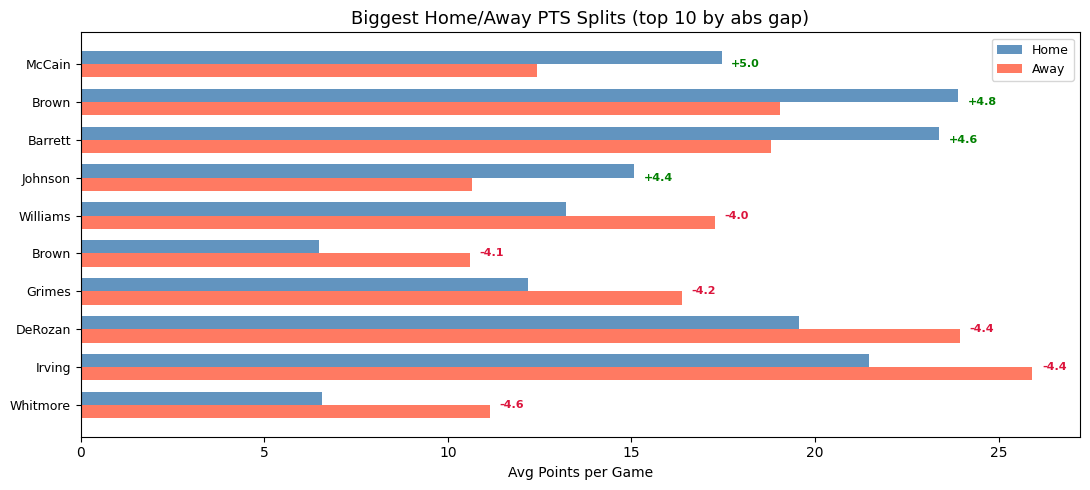

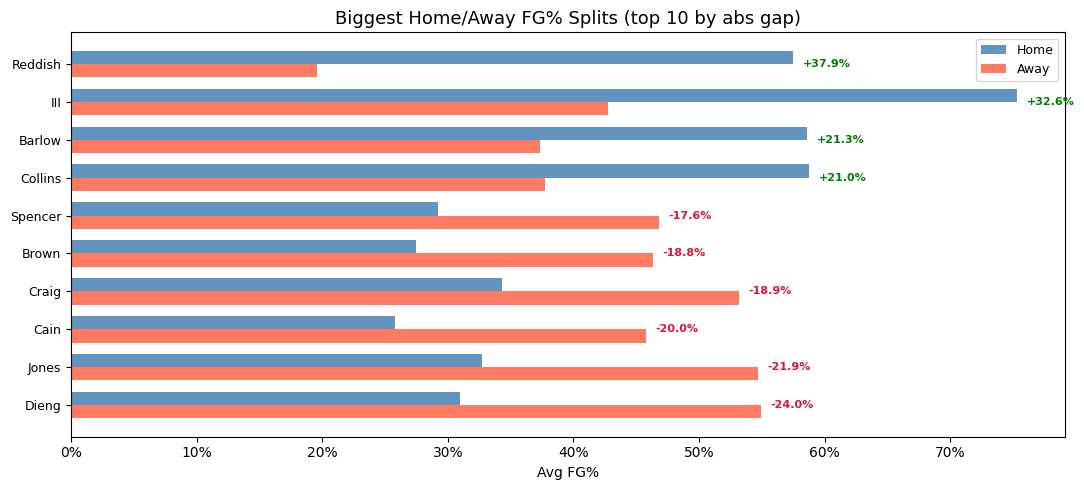

In [10]:
def paired_bar(df_wide, stat, title, ylabel, fmt=None, n=10):
    top = df_wide.reindex(df_wide[f'{stat}_diff'].abs().nlargest(n).index)
    top = top.sort_values(f'{stat}_diff', ascending=True)

    names = top['PLAYER_NAME'].str.split().str[-1]  # last name only
    x = np.arange(len(names))
    w = 0.35

    home_vals = top[f'{stat}_home'].values
    away_vals = top[f'{stat}_away'].values
    diffs     = top[f'{stat}_diff'].values

    fig, ax = plt.subplots(figsize=(11, 5))
    bars_h = ax.barh(x + w/2, home_vals, w, label='Home', color='steelblue', alpha=0.85)
    bars_a = ax.barh(x - w/2, away_vals, w, label='Away', color='tomato',    alpha=0.85)

    # Annotate the delta on the longer bar
    for i, (h, a, d) in enumerate(zip(home_vals, away_vals, diffs)):
        sign = '+' if d >= 0 else ''
        label = f'{sign}{d:.1f}' if fmt is None else f'{sign}{d:.1%}'
        x_pos = max(h, a) + (max(home_vals.max(), away_vals.max()) * 0.01)
        ax.text(x_pos, x[i], label, va='center', fontsize=8,
                color='green' if d > 0 else 'crimson', fontweight='bold')

    ax.set_yticks(x)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    if fmt == 'pct':
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
    plt.tight_layout()
    plt.show()

paired_bar(wide, 'pts',    'Biggest Home/Away PTS Splits (top 10 by abs gap)',   'Avg Points per Game')
paired_bar(wide, 'fg_pct', 'Biggest Home/Away FG% Splits (top 10 by abs gap)',   'Avg FG%', fmt='pct')

## Step 5: Distribution — Violin Plots
Show the full per-game distribution at home vs. away for PTS and FG%, limited to the same qualifying pool.

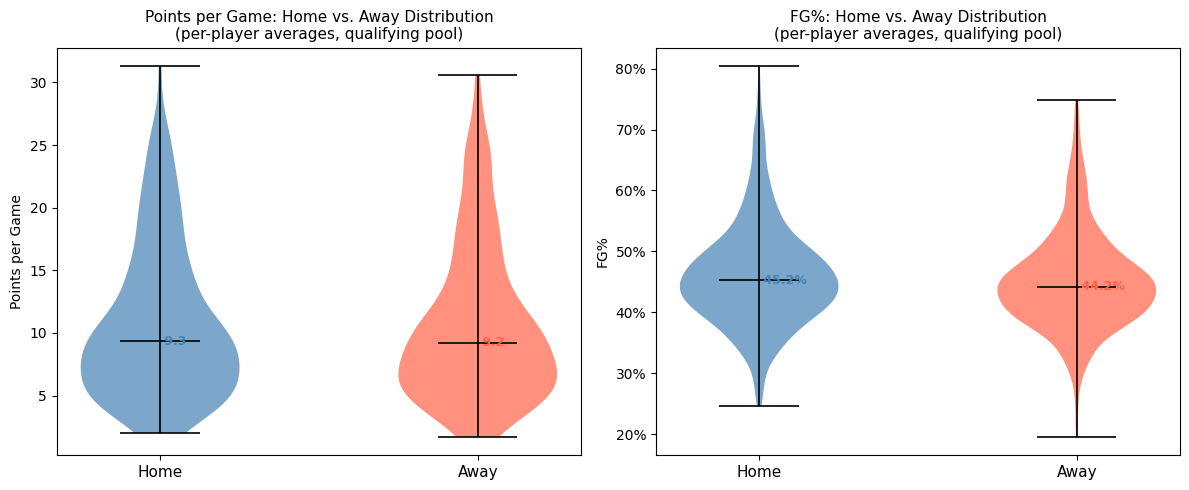

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label, pct_fmt in zip(
    axes,
    ['pts', 'fg_pct'],
    ['Points per Game', 'FG%'],
    [False, True]
):
    home_data = agg[agg['location'] == 'Home'][col].dropna()
    away_data = agg[agg['location'] == 'Away'][col].dropna()

    parts = ax.violinplot([home_data, away_data], positions=[1, 2], showmedians=True, showextrema=True)

    colors = ['steelblue', 'tomato']
    for body, color in zip(parts['bodies'], colors):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    for part in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
        parts[part].set_color('black')
        parts[part].set_linewidth(1.2)

    home_med = home_data.median()
    away_med = away_data.median()
    ax.text(1, home_med, f' {home_med:.1f}' if not pct_fmt else f' {home_med:.1%}',
            va='center', fontsize=9, color='steelblue', fontweight='bold')
    ax.text(2, away_med, f' {away_med:.1f}' if not pct_fmt else f' {away_med:.1%}',
            va='center', fontsize=9, color='tomato', fontweight='bold')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Home', 'Away'], fontsize=11)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'{label}: Home vs. Away Distribution\n(per-player averages, qualifying pool)', fontsize=11)
    if pct_fmt:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))

plt.tight_layout()
plt.show()

## Step 6: Delta Scatter — PTS Gap vs. FG% Gap
Each dot is a player. Position shows how their scoring gap relates to their efficiency gap. Labeled outliers have large combined splits.

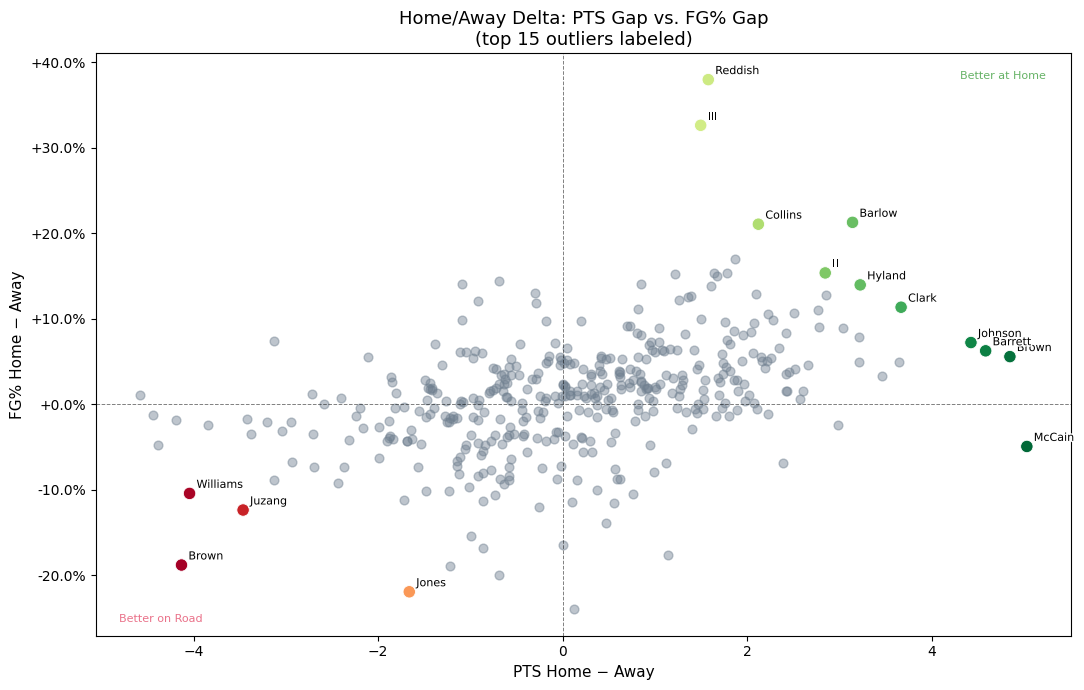

In [12]:
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(wide['pts_diff'], wide['fg_pct_diff'], alpha=0.45, s=40, color='slategrey', zorder=1)

# Highlight outliers: top 15 by combined z-score of abs deltas
wide['z_pts']    = (wide['pts_diff'].abs()    - wide['pts_diff'].abs().mean())    / wide['pts_diff'].abs().std()
wide['z_fg_pct'] = (wide['fg_pct_diff'].abs() - wide['fg_pct_diff'].abs().mean()) / wide['fg_pct_diff'].abs().std()
wide['z_combined'] = wide['z_pts'] + wide['z_fg_pct']

outliers = wide.nlargest(15, 'z_combined')

ax.scatter(outliers['pts_diff'], outliers['fg_pct_diff'],
           c=outliers['pts_diff'], cmap='RdYlGn', s=80,
           edgecolors='white', linewidths=0.6, zorder=2)

for _, row in outliers.iterrows():
    label = row['PLAYER_NAME'].split()[-1]
    ax.annotate(
        label,
        xy=(row['pts_diff'], row['fg_pct_diff']),
        xytext=(5, 4), textcoords='offset points',
        fontsize=8,
        path_effects=[pe.withStroke(linewidth=2, foreground='white')]
    )

ax.axvline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax.set_xlabel('PTS Home − Away', fontsize=11)
ax.set_ylabel('FG% Home − Away', fontsize=11)
ax.set_title('Home/Away Delta: PTS Gap vs. FG% Gap\n(top 15 outliers labeled)', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.1%}'))

# Quadrant labels
xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.text(xlim[1]*0.95, ylim[1]*0.95, 'Better at Home', ha='right', va='top',   fontsize=8, color='green',  alpha=0.6)
ax.text(xlim[0]*0.95, ylim[0]*0.95, 'Better on Road',  ha='left',  va='bottom', fontsize=8, color='crimson', alpha=0.6)

plt.tight_layout()
plt.show()